<a href="https://colab.research.google.com/github/mitalidaduria/.github/blob/main/Identifying_Key_Entities_Recipe_Data_Starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Identifying Key Entities in Recipe Data**


**Business Objective**:
The goal of this assignment is to train a Named Entity Recognition (NER) model using Conditional Random Fields (CRF) to extract key entities from recipe data. The model will classify words into predefined categories such as ingredients, quantities and units, enabling the creation of a structured database of recipes and ingredients that can be used to power advanced features in recipe management systems, dietary tracking apps, or e-commerce platforms.

### **Data Description**
The given data is in JSON format, representing a **structured recipe ingredient list** with **Named Entity Recognition (NER) labels**. Below is a breakdown of the data fields:

```json
[
    {
        "input": "6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil",
        "pos": "quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient"
    },
    {
      "input": "2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida",
      "pos": "quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient"
    }
]


| **Key**  | **Description**  |
|----------|-----------------|
| `input`  | Contains a raw ingredient list from a recipe. |
| `pos`    | Represents the corresponding part-of-speech (POS) tags or NER labels, identifying quantities, ingredients, and units. |


## **1** Import libraries

#### **1.1** Installation of sklearn-crfsuite

sklearn-crfsuite is a Python wrapper for CRFsuite, a fast and efficient implementation of Conditional Random Fields (CRFs). It is designed to integrate seamlessly with scikit-learn for structured prediction tasks such as Named Entity Recognition (NER), Part-of-Speech (POS) tagging, and chunking.

In [66]:
# installation of sklearn_crfsuite
!pip install sklearn_crfsuite==0.5.0

#### **1.2** Import necessary libraries

In [67]:
# Import warnings
import warnings
warnings.filterwarnings('ignore')

In [68]:
# Import necessary libraries
import json  # For handling JSON data
import pandas as pd  # For data manipulation and analysis
import re  # For regular expressions (useful for text preprocessing)
import matplotlib.pyplot as plt  # For visualisation
import seaborn as sns  # For advanced data visualisation
import sklearn_crfsuite  # CRF (Conditional Random Fields) implementation for sequence modeling
import numpy as np  # For numerical computations
# Saving and loading machine learning models
import joblib
import random
import spacy
from IPython.display import display, Markdown # For displaying well-formatted output

from fractions import Fraction  # For handling fractional values in numerical data
# Importing tools for feature engineering and model training
from collections import Counter  # For counting occurrences of elements in a list
from sklearn.model_selection import train_test_split  # For splitting dataset into train and test sets
from sklearn_crfsuite import metrics  # For evaluating CRF models
from sklearn_crfsuite.metrics import flat_classification_report
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from sklearn.metrics import confusion_matrix

In [69]:
# Ensure pandas displays full content
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

## **2** Data Ingestion and Preparation <font color = red>[25 marks]</font> <br>

#### **2.1** *Read Recipe Data from Dataframe and prepare the data for analysis* <font color = red>[12 marks]</font> <br>
Read the data from JSON file, print first five rows and describe the dataframe

In [137]:
def load_json_dataframe(file_path):
    with open(file_path, "r") as f:
        data = json.load(f)
    return pd.DataFrame(data)


# Call function
df = load_json_dataframe("ingredient_and_quantity.json")
print("Dataset Shape:", df.shape)
display(df.head())
print(df.info())

Dataset Shape: (285, 2)


,input,pos
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil,quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida,quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced 1/2 cup Carrots Gajjar chopped 1/3 Green peas Matar 2 Chillies 1/4 teaspoon Asafoetida hing Mustard seeds White Urad Dal Split Ghee sprig Curry leaves Salt Lemon juice,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 Green Chillies slit inch Ginger finely 6 cloves Garlic 1/2 teaspoon Turmeric powder Haldi Garam masala tablespoon Sesame Gingelly Oil 1/4 Methi Seeds Fenugreek Coriander Dhania Dry Red Fennel seeds Saunf cups Sorrel Leaves Gongura picked and,quantity unit ingredient quantity ingredient ingredient quantity ingredient quantity ingredient ingredient ingredient unit ingredient ingredient quantity unit ingredient quantity unit ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient
4,1 tablespoon chana dal white urad 2 red chillies coriander seeds 3 inches ginger onion tomato Teaspoon mustard asafoetida sprig curry,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient unit ingredient ingredient unit ingredient


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   input   285 non-null    object
 1   pos     285 non-null    object
dtypes: object(2)
memory usage: 4.6+ KB
None


##### **2.1.1** **Define a *load_json_dataframe* function** <font color = red>[7 marks]</font> <br>

Define a function that takes path of the ingredient_and_quantity.json file and reads it, convert it into dataframe - df and return it.

In [140]:
# define a function to load json file to a dataframe
def load_json_dataframe(file_path):
    with open(file_path, "r") as f:
        data = json.load(f)
    return pd.DataFrame(data)

##### **2.1.2** **Execute the *load_json_dataframe* function** <font color = red>[2 marks]</font> <br>

In [141]:
# read the json file by giving the file path and create a dataframe
df = load_json_dataframe("ingredient_and_quantity.json")

##### **2.1.3** **Describe the dataframe** <font color = red>[3 marks]</font> <br>

Print first five rows of dataframe along with dimensions. Display the information of dataframe

In [142]:
# display first five rows of the dataframe - df
display(df.head())

,input,pos
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil,quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida,quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced 1/2 cup Carrots Gajjar chopped 1/3 Green peas Matar 2 Chillies 1/4 teaspoon Asafoetida hing Mustard seeds White Urad Dal Split Ghee sprig Curry leaves Salt Lemon juice,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 Green Chillies slit inch Ginger finely 6 cloves Garlic 1/2 teaspoon Turmeric powder Haldi Garam masala tablespoon Sesame Gingelly Oil 1/4 Methi Seeds Fenugreek Coriander Dhania Dry Red Fennel seeds Saunf cups Sorrel Leaves Gongura picked and,quantity unit ingredient quantity ingredient ingredient quantity ingredient quantity ingredient ingredient ingredient unit ingredient ingredient quantity unit ingredient quantity unit ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient
4,1 tablespoon chana dal white urad 2 red chillies coriander seeds 3 inches ginger onion tomato Teaspoon mustard asafoetida sprig curry,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient unit ingredient ingredient unit ingredient


In [143]:
# print the dimensions of dataframe - df
print("Dimensions of DataFrame:", df.shape)

Dimensions of DataFrame: (285, 2)


In [144]:
# print the information of the dataframe
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   input   285 non-null    object
 1   pos     285 non-null    object
dtypes: object(2)
memory usage: 4.6+ KB
None


#### **2.2** *Recipe Data Manipulation* <font color = red>[13 marks]</font> <br>
Create derived metrics in dataframe and provide insights of the dataframe

In [139]:
# 2.2.1 Create token lists
df["input_tokens"] = df["input"].apply(lambda x: x.split())
df["pos_tokens"] = df["pos"].apply(lambda x: x.split())

# 2.2.2 Check token lengths
df["input_length"] = df["input_tokens"].apply(len)
df["pos_length"] = df["pos_tokens"].apply(len)


# 2.2.3 Check unique labels & label alignment
def unique_labels(df_col):
    labels = set()
    for item in df_col:
        labels.update(item)
    return labels


print("Unique POS/NER Labels:", unique_labels(df["pos_tokens"]))

# 2.2.4 & 2.2.5 Drop length mismatch rows & update metrics
invalid_rows = df[df["input_length"] != df["pos_length"]].index
df = df.drop(index=invalid_rows).reset_index(drop=True)

# 2.2.6 Re-verify alignment
unequal_count = len(df[df["input_length"] != df["pos_length"]])
print(f"Remaining mismatched rows: {unequal_count}")

Unique POS/NER Labels: {'unit', 'ingredient', 'quantity'}
Remaining mismatched rows: 0


##### **2.2.1** **Create input_tokens and pos_tokens columns by splitting the input and pos from the dataframe** <font color = red>[3 marks]</font> <br>
Split the input and pos into input_tokens and pos_tokens in the dataframe and display it in the dataframe

In [75]:
# split the input and pos into input_tokens and pos_tokens in the dataframe

# Tokenize input
# Tokenize POS

In [76]:
# display first five rows of the dataframe - df


In [145]:
df["input_tokens"] = df["input"].apply(lambda x: x.split())
df["pos_tokens"] = df["pos"].apply(lambda x: x.split())
display(df[["input_tokens", "pos_tokens"]].head())

,input_tokens,pos_tokens
0,"[6, Karela, Bitter, Gourd, Pavakkai, Salt, 1, Onion, 3, tablespoon, Gram, flour, besan, 2, teaspoons, Turmeric, powder, Haldi, Red, Chilli, Cumin, seeds, Jeera, Coriander, Powder, Dhania, Amchur, Dry, Mango, Sunflower, Oil]","[quantity, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]"
1,"[2-1/2, cups, rice, cooked, 3, tomatoes, teaspoons, BC, Belle, Bhat, powder, 1, teaspoon, chickpea, lentils, 1/2, cumin, seeds, white, urad, dal, mustard, green, chilli, dry, red, 2, cashew, or, peanuts, 1-1/2, tablespoon, oil, asafoetida]","[quantity, unit, ingredient, ingredient, quantity, ingredient, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient]"
2,"[1-1/2, cups, Rice, Vermicelli, Noodles, Thin, 1, Onion, sliced, 1/2, cup, Carrots, Gajjar, chopped, 1/3, Green, peas, Matar, 2, Chillies, 1/4, teaspoon, Asafoetida, hing, Mustard, seeds, White, Urad, Dal, Split, Ghee, sprig, Curry, leaves, Salt, Lemon, juice]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient]"
3,"[500, grams, Chicken, 2, Onion, chopped, 1, Tomato, 4, Green, Chillies, slit, inch, Ginger, finely, 6, cloves, Garlic, 1/2, teaspoon, Turmeric, powder, Haldi, Garam, masala, tablespoon, Sesame, Gingelly, Oil, 1/4, Methi, Seeds, Fenugreek, Coriander, Dhania, Dry, Red, Fennel, seeds, Saunf, cups, Sorrel, Leaves, Gongura, picked, and]","[quantity, unit, ingredient, quantity, ingredient, ingredient, quantity, ingredient, quantity, ingredient, ingredient, ingredient, unit, ingredient, ingredient, quantity, unit, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient]"
4,"[1, tablespoon, chana, dal, white, urad, 2, red, chillies, coriander, seeds, 3, inches, ginger, onion, tomato, Teaspoon, mustard, asafoetida, sprig, curry]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, unit, ingredient, ingredient, unit, ingredient]"


##### **2.2.2** **Provide the length for input_tokens and pos_tokens and validate their length** <font color = red>[2 marks]</font> <br>

Create input_length and pos_length columns in the dataframe and validate both the lengths. Check for the rows that are unequal in input and pos length


In [77]:
# create input_length and pos_length columns for the input_tokens and pos-tokens


In [78]:
# check for the equality of input_length and pos_length in the dataframe


In [146]:
df["input_length"] = df["input_tokens"].apply(len)
df["pos_length"] = df["pos_tokens"].apply(len)

mismatched = df[df["input_length"] != df["pos_length"]]
print(f"Number of mismatched rows: {len(mismatched)}")
display(mismatched.head())

Number of mismatched rows: 5


,input,pos,input_tokens,pos_tokens,input_length,pos_length
17,2 cups curd 1 cup gourd cucumber green cor coriander 1/2 teaspoon cumin powder salt,quantity unit ingredient quantity unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient,"[2, cups, curd, 1, cup, gourd, cucumber, green, cor, coriander, 1/2, teaspoon, cumin, powder, salt]","[quantity, unit, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient]",15,14
27,1 Baguette sliced 1 1/2 tablespoon Butter 1/2 Garlic minced cup Spinach Leaves Palak Red Bell pepper Capsicum Tomato finely chopped Onion Black powder Italian seasoning teaspoon Fresh cream Cheddar cheese grated Salt Roasted tomato pasta sauce,quantity ingredient ingredient quantity unit ingredient quantity ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[1, Baguette, sliced, 1, 1/2, tablespoon, Butter, 1/2, Garlic, minced, cup, Spinach, Leaves, Palak, Red, Bell, pepper, Capsicum, Tomato, finely, chopped, Onion, Black, powder, Italian, seasoning, teaspoon, Fresh, cream, Cheddar, cheese, grated, Salt, Roasted, tomato, pasta, sauce]","[quantity, ingredient, ingredient, quantity, unit, ingredient, quantity, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",37,36
79,1/2 cup Poha Flattened rice 2 tablespoons Rice flour 2 1/2 liter Milk 1 Nolen Gur or brown sugar Cardamom Elaichi Pods/Seeds 8-10 Mixed nuts almonds/cashews tablespoon Raisins pinch Saffron strands and a little more for garnish Salt,quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient quantity unit ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient unit ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[1/2, cup, Poha, Flattened, rice, 2, tablespoons, Rice, flour, 2, 1/2, liter, Milk, 1, Nolen, Gur, or, brown, sugar, Cardamom, Elaichi, Pods/Seeds, 8-10, Mixed, nuts, almonds/cashews, tablespoon, Raisins, pinch, Saffron, strands, and, a, little, more, for, garnish, Salt]","[quantity, unit, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, unit, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, unit, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",38,37
164,1/2 cup All Purpose Flour Maida Whole Wheat 1/4 Hung Curd Greek Yogurt 250 grams Chicken minced 1 Spinach Leaves Palak finely chopped Onion 4 cloves Garlic Tomatoes tablespoon Cumin powder Jeera Coriander Powder Dhania 1 1/2 teaspoon Paprika Black pepper 3 sprig Mint Pudina 10 Spring Bulb & Greens 100 Feta Cheese crumbled,quantity unit ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient,"[

##### **2.2.3** **Define a unique_labels function and validate the labels in pos_tokens** <font color = red>[2 marks]</font> <br>

Define a unique_labels function which checks for all the unique pos labels in the recipe & execute it.


In [79]:
# Define a unique_labels function to checks for all the unique pos labels in the recipe & print it


In [147]:
def unique_labels(pos_series):
    labels = set()
    for item in pos_series:
        labels.update(item)
    return labels


print("Unique POS/NER Labels:", unique_labels(df["pos_tokens"]))

Unique POS/NER Labels: {'unit', 'ingredient', 'quantity'}


##### **2.2.3** **Provide the insights seen in the recipe data after validation** <font color = red>[1 marks]</font> <br>

Provide the indexes that requires cleaning and formatting in the dataframe

<font color = red>[write your answer]</font> <br>


In [148]:
def unique_labels(pos_series):
    labels = set()
    for item in pos_series:
        labels.update(item)
    return labels


print("Unique POS/NER Labels:", unique_labels(df["pos_tokens"]))

Unique POS/NER Labels: {'unit', 'ingredient', 'quantity'}


##### **2.2.4** **Drop the rows that have invalid data provided in previous cell** <font color = red> [2 marks]</font> <br>

In [80]:
# drop the irrelevant recipe data


In [149]:
invalid_indices = df[df["input_length"] != df["pos_length"]].index
df = df.drop(index=invalid_indices).reset_index(drop=True)
print(f"Dropped {len(invalid_indices)} invalid rows. Remaining rows: {len(df)}")

Dropped 5 invalid rows. Remaining rows: 280


##### **2.2.5** **Update the input_length & pos_length in dataframe**<font color = red> [2 marks]</font> <br>

In [81]:
# update the input and pos length in input_length and pos_length


In [150]:
df["input_length"] = df["input_tokens"].apply(len)
df["pos_length"] = df["pos_tokens"].apply(len)

##### **2.2.6** **Validate the input_length and pos_length by checking unequal rows** <font color = red> [1 marks]</font> <br>

In [82]:
# validate the input length and pos length as input_length and pos_length


In [151]:
unequal_count = len(df[df["input_length"] != df["pos_length"]])
print(f"Remaining mismatched rows: {unequal_count}")

Remaining mismatched rows: 0


## **3** Train Validation Split (70 train - 30 val) <font color = red>[6 marks]</font> <br>

#### **3.1** *Perform train and validation split ratio* <font color = red>[6 marks]</font> <br>
Split the dataset with the help of input_tokens and pos_tokens and make a ratio of 70:30 split for training and validation datasets.

###### **3.1.1** **Split the dataset into train_df and val_df into 70:30 ratio** <font color = red> [1 marks]</font> <br>

In [83]:
# split the dataset into training and validation sets


In [152]:
train_df, val_df = train_test_split(df, test_size=0.30, random_state=42)

###### **3.1.2** **Print the first five rows of train_df and val_df** <font color = red> [1 marks]</font> <br>

In [153]:
# print the first five rows of train_df
print("=== Train Dataframe (First 5 rows) ===")
display(train_df.head())

=== Train Dataframe (First 5 rows) ===


,input,pos,input_tokens,pos_tokens,input_length,pos_length
175,250 grams Okra Oil 1 Onion finely chopped Tomato Grated teaspoon Ginger 2 Garlic Finely 1/2 Cumin seeds 1/4 Teaspoon asafoetida cup cottage cheese pinched coriander powder mango red chilli turmeric,quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient unit ingredient quantity ingredient ingredient quantity ingredient ingredient quantity unit ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[250, grams, Okra, Oil, 1, Onion, finely, chopped, Tomato, Grated, teaspoon, Ginger, 2, Garlic, Finely, 1/2, Cumin, seeds, 1/4, Teaspoon, asafoetida, cup, cottage, cheese, pinched, coriander, powder, mango, red, chilli, turmeric]","[quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, quantity, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",31,31
55,200 grams Paneer Homemade Cottage Cheese 2 Potato Aloo Bay leaf tej patta Dry Red Chilli 1 tablespoon Panch Phoran Masala roasted and powdered Tomato big sized teaspoon Turmeric powder Haldi Cumin seeds Jeera Ginger grated Salt 1/2 Sugar Sunflower Oil,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient,"[200, grams, Paneer, Homemade, Cottage, Cheese, 2, Potato, Aloo, Bay, leaf, tej, patta, Dry, Red, Chilli, 1, tablespoon, Panch, Phoran, Masala, roasted, and, powdered, Tomato, big, sized, teaspoon, Turmeric, powder, Haldi, Cumin, seeds, Jeera, Ginger, grated, Salt, 1/2, Sugar, Sunflower, Oil]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient]",41,41
109,500 grams Cabbage Patta Gobi Muttaikose 1 teaspoon Mustard seeds 1-1/2 White Urad Dal Split sprig Curry leaves Green Chilli 1/4 cup Fresh coconut Salt,quantity unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient,"[500, grams, Cabbage, Patta, Gobi, Muttaikose, 1, teaspoon, Mustard, seeds, 1-1/2, White, Urad, Dal, Split, sprig, Curry, leaves, Green, Chilli, 1/4, cup, Fresh, coconut, Salt]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient]",25,25
213,500 grams Fresh Figs 1/4 cup Lemon juice 1 teaspoon zest 2 Red Chilli flakes 1/2 Honey Brown Sugar (Demerara Sugar),quantity unit ingredient ingredient quantity unit ingredient ingredient quantity unit ingredient quantity ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient,"[500, grams, Fresh, Figs, 1/4, cup, Lemon, juice, 1, teaspoon, zest, 2, Red, Chilli, flakes, 1/2, Honey, Brown, Sugar, (Demerara, Sugar)]","[quantity, unit, ingredient, ingredient, quantity, unit, ingredient, ingredient, qua

In [154]:
# print the first five rows of the val_df
print("=== Validation Dataframe (First 5 rows) ===")
display(val_df.head())

=== Validation Dataframe (First 5 rows) ===


,input,pos,input_tokens,pos_tokens,input_length,pos_length
33,1 cup Ada 2 liter Milk 3/4 Sugar tablespoon Ghee 1/2 teaspoon Cardamom Powder Elaichi,quantity unit ingredient quantity unit ingredient quantity ingredient unit ingredient quantity unit ingredient ingredient ingredient,"[1, cup, Ada, 2, liter, Milk, 3/4, Sugar, tablespoon, Ghee, 1/2, teaspoon, Cardamom, Powder, Elaichi]","[quantity, unit, ingredient, quantity, unit, ingredient, quantity, ingredient, unit, ingredient, quantity, unit, ingredient, ingredient, ingredient]",15,15
108,1 Carrot Gajjar chopped 7 Potatoes Aloo 2 cups Cauliflower gobi cut to small florets Onion tablespoon Ginger Garlic Paste Salt teaspoons Sunflower Oil 1/2 cup Fresh coconut grated teaspoon Whole Black Peppercorns Green Chillies Fennel seeds Saunf Poppy 6 Cashew nuts inch Cinnamon Stick Dalchini Star anise 3 Cloves Laung Cardamom Elaichi Pods/Seeds Cumin Jeera,quantity ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient unit ingredient ingredient quantity unit ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[1, Carrot, Gajjar, chopped, 7, Potatoes, Aloo, 2, cups, Cauliflower, gobi, cut, to, small, florets, Onion, tablespoon, Ginger, Garlic, Paste, Salt, teaspoons, Sunflower, Oil, 1/2, cup, Fresh, coconut, grated, teaspoon, Whole, Black, Peppercorns, Green, Chillies, Fennel, seeds, Saunf, Poppy, 6, Cashew, nuts, inch, Cinnamon, Stick, Dalchini, Star, anise, 3, Cloves, Laung, Cardamom, Elaichi, Pods/Seeds, Cumin, Jeera]","[quantity, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",56,56
240,1 tablespoon Sunflower Oil 3 Potato Aloo Ginger paste Green Chilli chopped 1-1/12 tablespoons Sesame seeds Til teaspoon Red powder Cumin Jeera Coriander Powder Dhania 1/2 Garam masala 2 Sweet Chutney Date Tamarind Leaves few,quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient,"[1, tablespoon, Sunflower, Oil, 3, Potato, Aloo, Ginger, paste, Green, Chilli, chopped, 1-1/12, tablespoons, Sesame, seeds, Til, teaspoon, Red, powder, Cumin, Jeera, Coriander, Powder, Dhania, 1/2, Garam, masala, 2, Sweet, Chutney, Date, Tamarind, Leaves, few]","[quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",35,35
259,1 cup green peas gram flour 1/2 cheese tsp ginger 2 chillies turmeric powder cumin teaspoon salt oil,quantity unit ingredient ingredient ingredient ingredient quantity ingredient unit ingredient quantity ingredient i

###### **3.1.3** **Extract the dataset into train_df and val_df into X_train, X_val, y_train and y_val and display their length** <font color = red> [2 marks]</font> <br>

Extract X_train, X_val, y_train and y_val by extracting the list of input_tokens and pos_tokens from train_df and val_df and also display their length

In [155]:
# extract the training and validation sets by taking input_tokens and pos_tokens
X_train = train_df["input_tokens"].tolist()
y_train = train_df["pos_tokens"].tolist()

X_val = val_df["input_tokens"].tolist()
y_val = val_df["pos_tokens"].tolist()

In [156]:
# validate the shape of training and validation samples
print(f"X_train samples: {len(X_train)} | y_train samples: {len(y_train)}")
print(f"X_val samples:   {len(X_val)} | y_val samples:   {len(y_val)}")

X_train samples: 196 | y_train samples: 196
X_val samples:   84 | y_val samples:   84


###### **3.1.4** **Display the number of unique labels present in y_train** <font color = red> [2 marks]</font> <br>

In [157]:
# Display the number of unique labels present in y_train
unique_y_train = set(label for sequence in y_train for label in sequence)
print("Unique target labels present in y_train:", unique_y_train)
print("Total number of unique labels:", len(unique_y_train))

Unique target labels present in y_train: {'ingredient', 'unit', 'quantity'}
Total number of unique labels: 3


## **4** Exploratory Recipe Data Analysis on Training Dataset <font color = red>[16 marks]</font> <br>

#### **4.1** *Flatten the lists for input_tokens & pos_tokens* <font color = red>[2 marks]</font> <br>

Define a function **flatten_list** for flattening the structure for input_tokens and pos_tokens. The input parameter passed to this function is a nested list.

Initialise the dataset_name with a value ***'Training'***




In [158]:
# flatten the list for nested_list (input_tokens, pos_tokens)
def flatten_list(nested_list):
    """Flattens a list of lists into a single continuous list."""
    return [item for sublist in nested_list for item in sublist]

In [159]:
# initialise the dataset_name
dataset_name = 'Training'

#### **4.2** *Extract and validate the tokens after using the flattening technique* <font color = red>[2 marks]</font> <br>

Define a function named ***extract_and_validate_tokens*** with parameters dataframe and dataset_name (Training/Validation), validate the length of input_tokens and pos_tokens from dataframe and display first 10 records for both the input_tokens and pos_tokens. Execute this function




In [160]:
# define a extract_and_validate_tokens with parameters (df, dataset_name)
# call the flatten_list and apply it on input_tokens and pos_tokens
# validate their length and display first 10 records having input and pos tokens
def extract_and_validate_tokens(df, dataset_name="Training"):
    """Flattens input and POS tokens, validates lengths, and prints the first 10 records."""
    flat_inputs = flatten_list(df["input_tokens"])
    flat_pos = flatten_list(df["pos_tokens"])

    print(
        f"=== {dataset_name} Dataset Token Validation ==="
    )
    print(f"Total Input Tokens: {len(flat_inputs)}")
    print(f"Total POS Tags:     {len(flat_pos)}")
    assert len(flat_inputs) == len(
        flat_pos
    ), "Mismatch between input tokens and POS tags!"

    print("\nFirst 10 Input Tokens:", flat_inputs[:10])
    print("First 10 POS Tags:    ", flat_pos[:10])
    return flat_inputs, flat_pos

In [161]:
# extract the tokens and its pos tags
flat_train_inputs, flat_train_pos = (
    extract_and_validate_tokens(train_df, dataset_name)
)

=== Training Dataset Token Validation ===
Total Input Tokens: 7114
Total POS Tags:     7114

First 10 Input Tokens: ['250', 'grams', 'Okra', 'Oil', '1', 'Onion', 'finely', 'chopped', 'Tomato', 'Grated']
First 10 POS Tags:     ['quantity', 'unit', 'ingredient', 'ingredient', 'quantity', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient']


#### **4.3** *Categorise tokens into labels (unit, ingredient, quantity)* <font color = red>[2 marks]</font> <br>

Define a function ***categorize_tokens*** to categorise tokens into ingredients, units and quantities by using extracted tokens in the previous code and return a list of ingredients, units and quantities. Execute this function to get the list.



In [162]:
# define a categorize_tokens function and provide the tokens and pos_tags as parameters and create ingredient, unit and quantity list and return it
# validate the list that it comprised of these labels, if not return empty arrays
def categorize_tokens(tokens, tags):
    """Categorizes flattened tokens into ingredients, units, and quantities."""
    ingredients, units, quantities = [], [], []
    for tok, tag in zip(tokens, tags):
        if tag == "ingredient":
            ingredients.append(tok.lower())
        elif tag == "unit":
            units.append(tok.lower())
        elif tag == "quantity":
            quantities.append(tok)
    return ingredients, units, quantities


In [163]:
#  call the function to categorise the labels into respective list
train_ingredients, train_units, train_quantities = (
    categorize_tokens(flat_train_inputs, flat_train_pos)
)
print(f"Total Ingredients: {len(train_ingredients)}")
print(f"Total Units:       {len(train_units)}")
print(f"Total Quantities:  {len(train_quantities)}")

Total Ingredients: 5323
Total Units:       811
Total Quantities:  980


#### **4.4** *Top 10 Most Frequent Items* <font color = red>[3 marks]</font> <br>

Define a function ***get_top_frequent_items*** to display top 10 most frequent items

Here, item_list is used as a general parameter where you will call this function for ingredient and unit list

Execute this function separately for top 10 most units and ingredients



In [164]:
# define a function get_top_frequent_items to get the top frequent items by using item_list, pos label and dataset_name(Training/Validation) and return top items
def get_top_frequent_items(
    item_list, pos_label="Item", dataset_name="Training", top_n=10
):
    """Returns top N most frequent items in a given list."""
    counts = Counter(item_list).most_common(top_n)
    print(
        f"Top {top_n} {pos_label}s in {dataset_name} Set:"
    )
    for item, freq in counts:
        print(f" - {item}: {freq}")
    return counts

In [165]:
# get the top ingredients which are frequently seen in the recipe
top_ingredients = get_top_frequent_items(
    train_ingredients, "Ingredient", dataset_name
)

Top 10 Ingredients in Training Set:
 - powder: 192
 - salt: 123
 - leaves: 120
 - oil: 111
 - seeds: 111
 - red: 110
 - green: 104
 - chilli: 96
 - coriander: 93
 - chopped: 84


In [166]:
# get the top units which are frequently seen in the recipe
top_units = get_top_frequent_items(
    train_units, "Unit", dataset_name
)

Top 10 Units in Training Set:
 - teaspoon: 165
 - cup: 136
 - tablespoon: 100
 - grams: 63
 - tablespoons: 62
 - inch: 52
 - cups: 50
 - sprig: 42
 - cloves: 39
 - teaspoons: 39


#### **4.5** *Plot Top 10 most frequent items* <font color = red>[2 marks]</font> <br>




Define a function ***plot_top_items*** to plot a bar graph on top 10 most frequent items for units and ingredients

Here, item_list is used as a general parameter where you will call this function for ingredient and unit list

In [167]:
# define plot top items with parameters - top_item list, label to suggest whether its ingredient or unit, dataset_name
def plot_top_items(
    top_item_list, label_type="Ingredient", dataset_name="Training"
):
    """Plots a horizontal bar chart of top frequent items."""
    items, counts = zip(*top_item_list)
    plt.figure(figsize=(10, 5))
    sns.barplot(
        x=list(counts), y=list(items), hue=list(items), legend=False, palette="viridis"
    )
    plt.title(
        f"Top 10 Most Frequent {label_type}s ({dataset_name} Set)",
        fontsize=14,
    )
    plt.xlabel("Frequency", fontsize=12)
    plt.ylabel(label_type, fontsize=12)
    plt.tight_layout()
    plt.show()

#### **4.6** *Perform EDA analysis* <font color = red>[5 marks]</font> <br>

Plot the bar plots for ingredients and units and provide the insights for training dataset

---



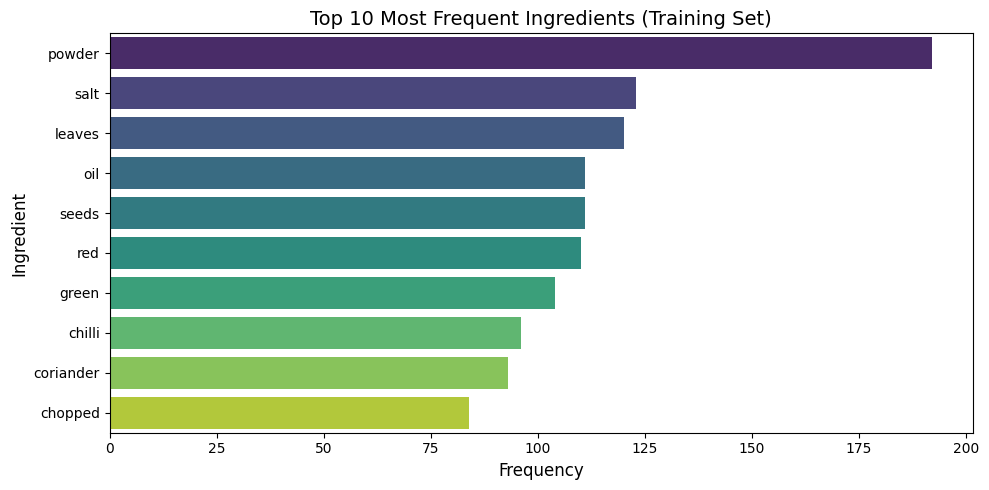

In [168]:
# plot the top frequent ingredients in training data
plot_top_items(top_ingredients, "Ingredient", dataset_name)

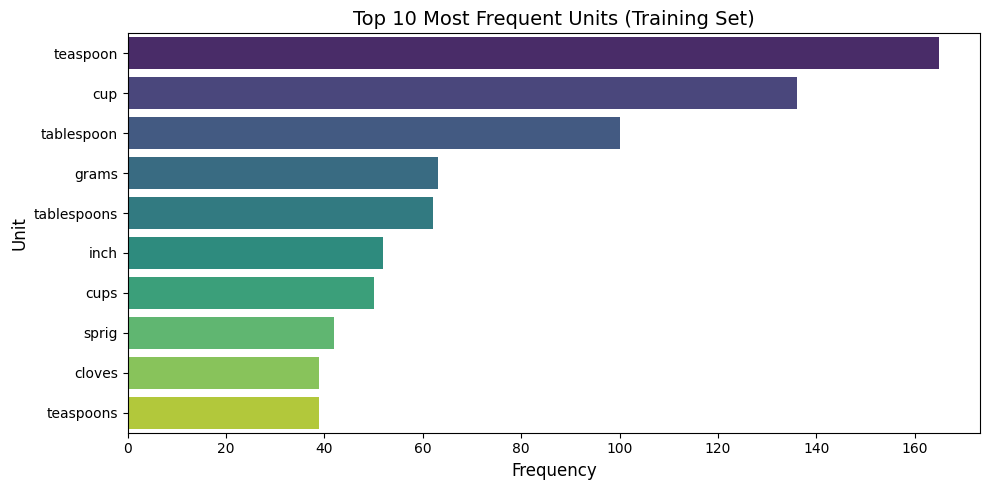

In [169]:
# plot the top frequent units in training data
plot_top_items(top_units, "Unit", dataset_name)

## **5** Exploratory Recipe Data Analysis on Validation Dataset (Optional)<font color = red> [0 marks]</font> <br>

#### **5.1** *Execute EDA on Validation Dataset with insights (Optional)* <font color = red> [0 marks]</font> <br>
Initialise the dataset_name as ***Validation*** and call the ***plot_top_items*** for top 10 ingredients and units in the recipe data
Provide the insights for the same.



In [170]:
# initialise the dataset_name
# Initialise the dataset_name as Validation
dataset_name = "Validation"

In [171]:
# use extract and validate tokens, categorise tokens, get top frequent items for ingredient list and unit list on validation dataframe
# Extract and validate tokens for Validation Set
flat_val_inputs, flat_val_pos = extract_and_validate_tokens(
    val_df, dataset_name
)

# Categorise tokens into ingredients, units, and quantities
val_ingredients, val_units, val_quantities = categorize_tokens(
    flat_val_inputs, flat_val_pos
)

# Get top 10 frequent ingredients and units
top_val_ingredients = get_top_frequent_items(
    val_ingredients, "Ingredient", dataset_name
)
top_val_units = get_top_frequent_items(val_units, "Unit", dataset_name)

=== Validation Dataset Token Validation ===
Total Input Tokens: 2876
Total POS Tags:     2876

First 10 Input Tokens: ['1', 'cup', 'Ada', '2', 'liter', 'Milk', '3/4', 'Sugar', 'tablespoon', 'Ghee']
First 10 POS Tags:     ['quantity', 'unit', 'ingredient', 'quantity', 'unit', 'ingredient', 'quantity', 'ingredient', 'unit', 'ingredient']
Top 10 Ingredients in Validation Set:
 - powder: 79
 - salt: 57
 - oil: 54
 - red: 52
 - leaves: 52
 - seeds: 50
 - chilli: 41
 - green: 37
 - garlic: 36
 - coriander: 33
Top 10 Units in Validation Set:
 - teaspoon: 59
 - cup: 57
 - tablespoon: 32
 - tablespoons: 32
 - cups: 24
 - sprig: 22
 - inch: 20
 - grams: 19
 - teaspoons: 18
 - cloves: 16


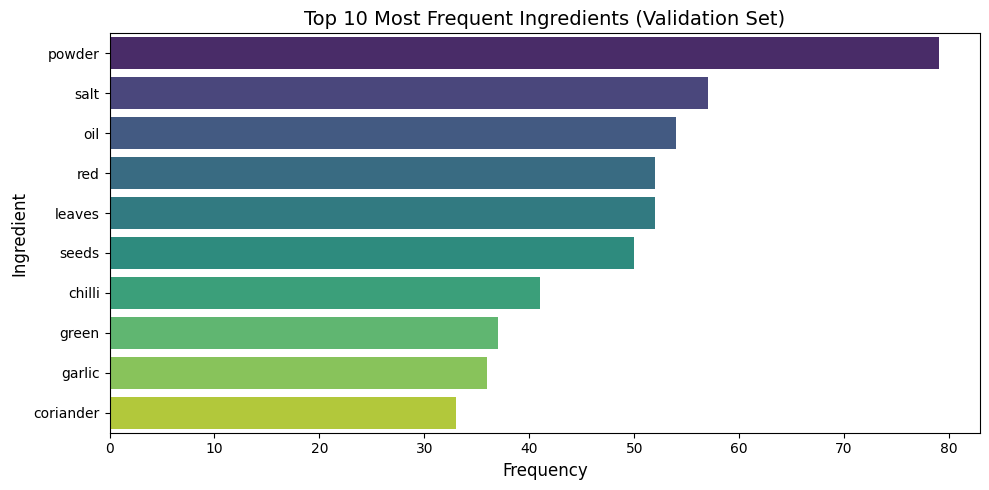

In [172]:
# plot the top frequent ingredients in validation data
# Plot the top frequent ingredients in validation data
plot_top_items(top_val_ingredients, "Ingredient", dataset_name)

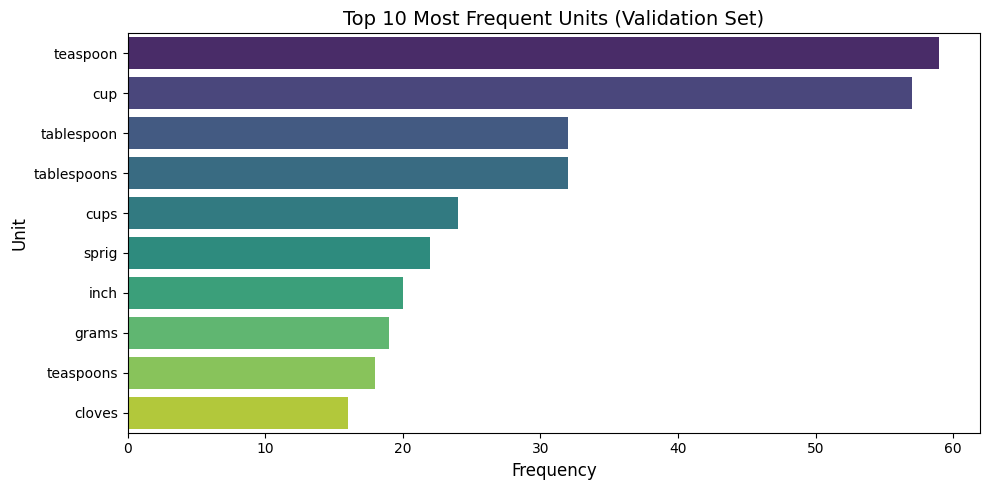

In [173]:
# plot the top frequent units in training data
# Plot the top frequent units in validation data
plot_top_items(top_val_units, "Unit", dataset_name)

## **6** Feature Extraction For CRF Model <font color = red>[30 marks]</font> <br>

### **6.1** *Define a feature functions to take each token from recipe* <font color = red>[10 marks]</font>

Define a function as ***word2features*** which takes a particular recipe and its index to work with all recipe input tokens and include custom key-value pairs.

Also, use feature key-value pairs to mark the beginning and end of the sequence and to also check whether the word belongs to unit, quantity etc. Use keyword sets for unit and quantity for differentiating feature functions well. Also make use of relevant regex patterns on fractions, whole numbers etc.

##### **6.1.1** **Define keywords for unit and quantity and create a quantity pattern to work on fractions, numbers and decimals** <font color = red>[3 marks]</font> <br>

Create sets for **unit_keywords** and ***quantity_keywords*** and include all the words relevant for measuring the ingredients such as cup, tbsp, tsp etc. and in quantity keywords, include words such as half, quarter etc.

Also suggested to use regex pattern as ***quantity_pattern*** to work with quantity in any format such as fractions, numbers and decimals.

Then, load the spacy model and process the entire sentence

In [174]:
# define unit and quantity keywords along with quantity pattern
import re
import spacy

# Load spaCy model
nlp = spacy.load("en_core_web_sm", disable=["ner", "textcat"])

# Define keyword sets
unit_keywords = {
    "cup",
    "cups",
    "tablespoon",
    "tablespoons",
    "tbsp",
    "teaspoon",
    "teaspoons",
    "tsp",
    "gram",
    "grams",
    "g",
    "kg",
    "ml",
    "l",
    "pinch",
    "clove",
    "cloves",
    "slice",
    "slices",
    "oz",
    "pound",
    "lbs",
    "sprig",
    "inch",
    "inches",
}

quantity_keywords = {
    "half",
    "quarter",
    "one",
    "two",
    "three",
    "four",
    "five",
    "six",
    "seven",
    "eight",
    "nine",
    "ten",
    "a",
    "an",
    "few",
}

# Regex pattern for quantities (fractions, decimals, ranges, integers)
quantity_pattern = re.compile(
    r"^(\d+|\d+/\d+|\d+\.\d+|\d+-\d+/\d+|\d+-\d+.\d+)$"
)

In [106]:
# load spaCy model


##### **6.1.2** **Define feature functions for CRF** <font color = red>[7 marks]</font> <br>

Define ***word2features*** function and use the parameters such as sentence and its indexing as ***sent*** and ***i*** for extracting token level features for CRF Training.
Build ***features*** dictionary, also mark the beginning and end of the sequence and use the ***unit_keywords***, ***quantity_keywords*** and ***quantity_pattern*** for knowing the presence of quantity or unit in the tokens

While building ***features*** dictionary, include
- ***Core Features*** - The core features of a token should capture its lexical
and grammatical properties. Include attributes like the raw token, its lemma, part-of-speech tag, dependency relation, and shape, as well as indicators for whether it's a stop word, digit, or punctuation. The details of the features are given below:

    - `bias` - Constant feature with a fixed value of 1.0 to aid model learning.
    - `token` - The lowercase form of the current token.
    - `lemma` - The lowercase lemma (base form) of the token.
    - `pos_tag` - Part-of-speech (POS) tag of the token.
    - `tag` - Detailed POS tag of the token.
    - `dep` - Dependency relation of the token in the sentence.
    - `shape` - Shape of the token (e.g., "Xxx" for "Milk").
    - `is_stop` - Boolean indicating if the token is a stopword.
    - `is_digit` - Boolean indicating if the token consists of only digits.
    - `has_digit` - Boolean indicating if the token contains at least one digit.
    - `has_alpha` - Boolean indicating if the token contains at least one alphabetic character.
    - `hyphenated` - Boolean indicating if the token contains a hyphen (-).
    - `slash_present` - Boolean indicating if the token contains a slash (/).
    - `is_title` - Boolean indicating if the token starts with an uppercase letter.
    - `is_upper` - Boolean indicating if the token is fully uppercase.
    - `is_punct` - Boolean indicating if the token is a punctuation mark.

- ***Improved Quantity and Unit Detection*** - Use key-value pairs to mark the presence of quantities and units in the features dictionary. Utilise the unit_keywords, quantity_keywords, and quantity_pattern to identify and flag these elements. The details of the features are given below:

    - `is_quantity` - Boolean indicating if the token matches a quantity pattern or keyword.
    - `is_unit` - Boolean indicating if the token is a known measurement unit.
    - `is_numeric` - Boolean indicating if the token matches a numeric pattern.
    - `is_fraction` - Boolean indicating if the token represents a fraction (e.g., 1/2).
    - `is_decimal` - Boolean indicating if the token represents a decimal number (e.g., 3.14).
    - `preceding_word` - The previous token in the sentence, if available.
    - `following_word` - The next token in the sentence, if available.

- ***Contextual Features*** - Incorporate contextual information by adding features for the preceding and following tokens. Include indicators like BOS and EOS to mark the beginning and end of the sequence, and utilise unit_keywords, quantity_keywords, and quantity_pattern to identify the types of neighboring tokens. The features are given below:

    - `prev_token` - The lowercase form of the previous token.
    - `prev_is_quantity` - Boolean indicating if the previous token is a quantity.
    - `prev_is_digit` - Boolean indicating if the previous token is a digit.
    - `BOS` - Boolean indicating if the token is at the beginning of the sentence.
    - `next_token` - The lowercase form of the next token.
    - `next_is_unit` - Boolean indicating if the next token is a unit.
    - `next_is_ingredient` - Boolean indicating if the next token is not a unit or quantity.
    - `EOS` - Boolean indicating if the token is at the end of the sentence.



In [107]:
# define word2features for processing each token in the sentence sent by using index i.
# use your own feature functions

    # Process the entire sentence with spaCy

    # --- Core Features ---

    # --- Improved Quantity & Unit Detection ---

    # --- Contextual Features ---


In [175]:
def word2features(sent, i):
    # Process sentence using spaCy for linguistic attributes
    doc = nlp(" ".join(sent))
    token = doc[i]

    word = sent[i]
    word_lower = word.lower()

    # --- Core Features ---
    features = {
        "bias": 1.0,
        "token": word_lower,
        "lemma": token.lemma_.lower(),
        "pos_tag": token.pos_,
        "tag": token.tag_,
        "dep": token.dep_,
        "shape": token.shape_,
        "is_stop": token.is_stop,
        "is_digit": word.isdigit(),
        "has_digit": any(c.isdigit() for c in word),
        "has_alpha": any(c.isalpha() for c in word),
        "hyphenated": "-" in word,
        "slash_present": "/" in word,
        "is_title": word.istitle(),
        "is_upper": word.isupper(),
        "is_punct": token.is_punct,
        # --- Quantity & Unit Features ---
        "is_quantity": bool(quantity_pattern.match(word))
        or (word_lower in quantity_keywords),
        "is_unit": word_lower in unit_keywords,
        "is_numeric": bool(re.match(r"^\d+(\.\d+)?$", word)),
        "is_fraction": bool(re.match(r"^\d+/\d+$", word)),
        "is_decimal": bool(re.match(r"^\d+\.\d+$", word)),
    }

    # --- Contextual Features (Previous Word) ---
    if i > 0:
        prev_word = sent[i - 1].lower()
        features.update(
            {
                "prev_token": prev_word,
                "prev_is_quantity": bool(quantity_pattern.match(prev_word))
                or (prev_word in quantity_keywords),
                "prev_is_digit": prev_word.isdigit(),
                "BOS": False,
            }
        )
    else:
        features["BOS"] = True

    # --- Contextual Features (Next Word) ---
    if i < len(sent) - 1:
        next_word = sent[i + 1].lower()
        features.update(
            {
                "next_token": next_word,
                "next_is_unit": next_word in unit_keywords,
                "next_is_ingredient": next_word
                not in (unit_keywords | quantity_keywords),
                "EOS": False,
            }
        )
    else:
        features["EOS"] = True

    return features


def sent2features(sent):
    return [word2features(sent, i) for i in range(len(sent))]

### **6.2** *Preparation of Recipe level features* <font color = red>[2 marks]</font>


##### **6.2.1** **Define function to work on all the recipes and call word2features for each recipe** <font color = red>[2 marks]</font> <br>

Define ***sent2features*** function and inputs ***sent*** as a parameter and correctly generate feature functions for each token present in the sentence

In [108]:
# define sent2features by working on each token in the sentence and correctly generate dictionaries for features


In [176]:
# define sent2features by working on each token in the sentence and correctly generate dictionaries for features
def sent2features(sent):
    return [word2features(sent, i) for i in range(len(sent))]

### **6.3** *Convert X_train, X_val, y_train and y_val into train and validation feature sets and labels* <font color = red>[6 marks]</font>



##### **6.3.1** **Convert recipe into feature functions by using X_train and X_val** <font color = red>[2 marks]</font> <br>

Create ***X_train_features*** and ***X_val_features*** as list to include the feature functions for each recipe present in training and validation sets

In [177]:
# Convert input sentences into feature sets by taking training and validation dataset as X_train_features and X_val_features
# Convert input sentences into feature sets by taking training and validation dataset as X_train_features and X_val_features
X_train_features = [sent2features(s) for s in X_train]
X_val_features = [sent2features(s) for s in X_val]

##### **6.3.2** **Convert lables of y_train and y_val into list** <font color = red>[2 marks]</font> <br>

Create ***y_train_labels*** and ***y_val_labels*** by using the list of y_train and y_val

In [178]:
# Convert labels into list as y_train_labels and y_val_labels
# Convert labels into list as y_train_labels and y_val_labels
y_train_labels = y_train
y_val_labels = y_val

##### **6.3.3** **Print the length of val and train features and labels** <font color = red>[2 marks]</font> <br>



In [179]:
# print the length of train features and labels
# print the length of train features and labels
print(f"X_train_features length: {len(X_train_features)}")
print(f"y_train_labels length: {len(y_train_labels)}")

X_train_features length: 196
y_train_labels length: 196


In [180]:
# print the length of validation features and labels
# print the length of validation features and labels
print(f"X_val_features length: {len(X_val_features)}")
print(f"y_val_labels length: {len(y_val_labels)}")

X_val_features length: 84
y_val_labels length: 84


### **6.4** *Applying weights to feature sets* <font color = red>[12 marks]</font> <br>




##### **6.4.1** **Flatten the labels of y_train** <font color = red>[2 marks]</font> <br>

Create ***y_train_flat*** to flatten the structure of nested y_train

In [181]:
# Flatten labels in y_train
# Flatten labels in y_train
y_train_flat = flatten_list(y_train_labels)

##### **6.4.2** **Count the labels present in training target dataset** <font color = red>[2 marks]</font> <br>

Create ***label_counts*** to count the frequencies of labels present in y_train_flat and retrieve the total samples by using the values of label_counts as ***total_samples***

In [182]:
# Count label frequencies as label_counts and total_samples as getting the summation of values of label_counts
# Count label frequencies as label_counts and total_samples as getting the summation of values of label_counts
label_counts = Counter(y_train_flat)
total_samples = sum(label_counts.values())

print("Label Counts:", label_counts)
print("Total Samples:", total_samples)

Label Counts: Counter({'ingredient': 5323, 'quantity': 980, 'unit': 811})
Total Samples: 7114


##### **6.4.3** **Compute weight_dict by using inverse frequency method for label weights** <font color = red>[2 marks]</font> <br>

- Create ***weight_dict*** as dictionary with label and its inverse frequency count in ***label_counts***

- Penalise ingredient label in the dictionary

In [183]:
# Compute class weights (inverse frequency method) by considering total_samples and label_counts
# Compute class weights (inverse frequency method) by considering total_samples and label_counts
weight_dict = {lbl: total_samples / count for lbl, count in label_counts.items()}

In [184]:
# penalise ingredient label
# penalise ingredient label
weight_dict["ingredient"] = weight_dict["ingredient"] * 0.5
print("Computed Weight Dict:", weight_dict)

Computed Weight Dict: {'quantity': 7.259183673469388, 'unit': 8.771886559802713, 'ingredient': 0.6682321998872816}


##### **6.4.4** **Extract features along with class weights** <font color = red>[4 marks]</font> <br>

Define a function ***extract_features_with_class_weights*** to work with training and validation datasets and extract features by applying class weights





In [185]:
# Apply weights to feature extraction in extract_features_with_class_weights by using parameters such as X (input tokens), y(labels) and weight_dict (Class weights)
# Apply weights to feature extraction in extract_features_with_class_weights by using parameters such as X (input tokens), y(labels) and weight_dict (Class weights)
def extract_features_with_class_weights(X, y, weight_dict):
    """
    Extracts features for the input sentences and maps them alongside the target labels.
    The class weights dictionary is passed through for model training reference.
    """
    X_feats = [sent2features(s) for s in X]
    return X_feats, y

##### **6.4.5** **Execute extract_features_with_class_weights on training and validation datasets** <font color = red>[2 marks]</font> <br>

Create ***X_train_weighted_features*** and ***X_val_weighted_features*** for extracting training and validation features along with their weights by calling ***extract_features_with_class_weights*** on the datasets

In [186]:
# Apply manually computed class weights
# Apply manually computed class weights
X_train_weighted_features, y_train_weighted = extract_features_with_class_weights(X_train, y_train_labels, weight_dict)
X_val_weighted_features, y_val_weighted = extract_features_with_class_weights(X_val, y_val_labels, weight_dict)

print("Features extracted successfully for training and validation datasets.")

Features extracted successfully for training and validation datasets.


## **7** Model Building and Training <font color = red>[10 marks]</font> <br>

### **7.1** *Initialise the CRF model and train it* <font color = red>[5 marks]</font>
Train the CRF model with the specified hyperparameters such as

### CRF Model Hyperparameters Explanation

| Parameter                  | Description |
|----------------------------|-------------|
| **algorithm='lbfgs'**      | Optimisation algorithm used for training. `lbfgs` (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) is a quasi-Newton optimisation method. |
| **c1=0.5**                | L1 regularisation term to control sparsity in feature weights. Helps in feature selection. |
| **c2=1.0**                | L2 regularisation term to prevent overfitting by penalising large weights. |
| **max_iterations=100**     | Maximum number of iterations for model training. Higher values allow more convergence but increase computation time. |
| **all_possible_transitions=True** | Ensures that all possible state transitions are considered in training, making the model more robust. |

Use weight_dict for training CRF



In [119]:
# initialise CRF model with the specified hyperparameters and use weight_dict

# train the CRF model with the weighted training data


In [187]:
# initialise CRF model with the specified hyperparameters and use weight_dict
crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.5,
    c2=1.0,
    max_iterations=100,
    all_possible_transitions=True
)

# train the CRF model with the weighted training data
crf.fit(X_train_weighted_features, y_train_weighted)
print("CRF Model trained successfully!")

CRF Model trained successfully!


### **7.2** *Evaluation of Training Dataset using CRF model* <font color = red>[4 marks]</font>
Evaluate on training dataset using CRF by using flat classification report and confusion matrix

In [120]:
# evaluate on the training dataset


In [188]:
# evaluate on the training dataset
y_pred_train = crf.predict(X_train_weighted_features)

In [189]:
# specify the flat classification report by using training data for evaluation
# specify the flat classification report by using training data for evaluation
print("=== Training Data Classification Report ===")
print(flat_classification_report(y_train_weighted, y_pred_train, digits=4))

=== Training Data Classification Report ===
              precision    recall  f1-score   support

  ingredient     0.9910    0.9968    0.9939      5323
    quantity     0.9959    0.9857    0.9908       980
        unit     0.9835    0.9581    0.9706       811

    accuracy                         0.9909      7114
   macro avg     0.9902    0.9802    0.9851      7114
weighted avg     0.9908    0.9909    0.9908      7114



In [190]:
# evaluate on the training dataset
y_pred_train = crf.predict(X_train_weighted_features)

In [191]:
# specify the flat classification report by using training data for evaluation
print("=== Training Data Classification Report ===")
print(flat_classification_report(y_train_weighted, y_pred_train, digits=4))

=== Training Data Classification Report ===
              precision    recall  f1-score   support

  ingredient     0.9910    0.9968    0.9939      5323
    quantity     0.9959    0.9857    0.9908       980
        unit     0.9835    0.9581    0.9706       811

    accuracy                         0.9909      7114
   macro avg     0.9902    0.9802    0.9851      7114
weighted avg     0.9908    0.9909    0.9908      7114



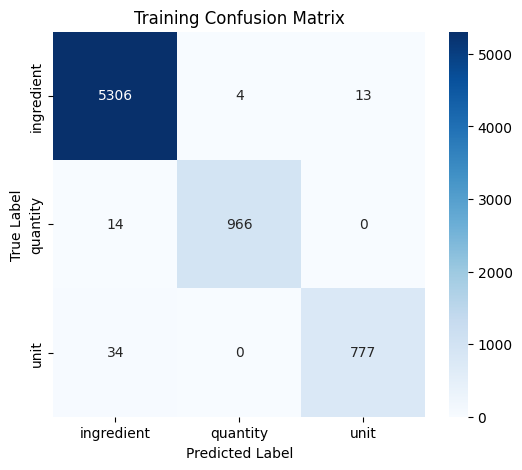

In [192]:
# create a confusion matrix on training datset
# create a confusion matrix on training datset
# Flatten the predictions to match the flattened true labels
flat_y_train = flatten_list(y_train_weighted)
flat_y_pred_train = flatten_list(y_pred_train)

# Get sorted unique labels
labels = sorted(list(unique_y_train))

# Compute and plot confusion matrix
cm_train = confusion_matrix(flat_y_train, flat_y_pred_train, labels=labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_train, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.title('Training Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### **7.3** *Save the CRF model* <font color = red>[1 marks]</font>
Save the CRF model

In [193]:
# dump the model using joblib as crf_model.pkl
# dump the model using joblib as crf_model.pkl
joblib.dump(crf, 'crf_model.pkl')
print("Model saved successfully as 'crf_model.pkl'")

Model saved successfully as 'crf_model.pkl'


## **8** Prediction and Model Evaluation <font color = red>[3 marks]</font> <br>

### **8.1** *Predict and Evaluate the CRF model on validation set* <font color = red>[3 marks]</font>
Evaluate the metrics for CRF model by using flat classification report and confusion matrix




In [194]:
# predict the crf model on validation dataset
# predict the crf model on validation dataset
y_pred_val = crf.predict(X_val_weighted_features)

In [195]:
# specify flat classification report
# specify flat classification report
print("=== Validation Data Classification Report ===")
print(flat_classification_report(y_val_weighted, y_pred_val, digits=4))

=== Validation Data Classification Report ===
              precision    recall  f1-score   support

  ingredient     0.9817    0.9953    0.9885      2107
    quantity     0.9902    0.9854    0.9878       411
        unit     0.9728    0.8994    0.9347       358

    accuracy                         0.9819      2876
   macro avg     0.9816    0.9600    0.9703      2876
weighted avg     0.9818    0.9819    0.9817      2876



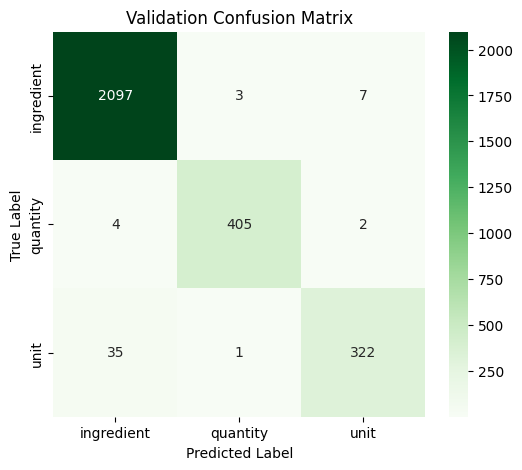

In [196]:
# create a confusion matrix on validation dataset
# create a confusion matrix on validation dataset
flat_y_val = flatten_list(y_val_weighted)
flat_y_pred_val = flatten_list(y_pred_val)

cm_val = confusion_matrix(flat_y_val, flat_y_pred_val, labels=labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_val, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Greens')
plt.title('Validation Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## **9** Error Analysis on Validation Data <font color = red>[10 marks]</font> <br>
Investigate misclassified samples in validation dataset and provide the insights


### **9.1** *Investigate misclassified samples in validation dataset* <font color = red>[8 marks]</font>



##### **9.1.1** Flatten the labels of validation data and initialise error data <font color = red>[2 marks]</font> <br>



Flatten the true and predicted labels and initialise the error data as ***error_data***

In [198]:
# flatten Labels and Initialise Error Data
# flatten Labels and Initialise Error Data
flat_y_val = flatten_list(y_val_labels)
flat_y_pred_val = flatten_list(y_pred_val)
error_data = []

##### **9.1.2** Iterate the validation data and collect Error Information<font color = red> [2 marks]</font> <br>



Iterate through validation data (X_val, y_val_labels, y_pred_val) and compare true vs. predicted labels. Collect error details, including surrounding context, previous/next tokens, and class weights, then store them in error_data

In [128]:
# iterate and collect Error Information

            # get previous and next tokens with handling for boundary cases


In [199]:
# iterate and collect Error Information
for sent_idx, (sent, true_seq, pred_seq) in enumerate(zip(X_val, y_val_labels, y_pred_val)):
    for i in range(len(sent)):
        if true_seq[i] != pred_seq[i]:
            # get previous and next tokens with handling for boundary cases
            prev_tok = sent[i - 1] if i > 0 else "<BOS>"
            next_tok = sent[i + 1] if i < len(sent) - 1 else "<EOS>"

            error_data.append({
                "token": sent[i],
                "prev_token": prev_tok,
                "next_token": next_tok,
                "true_label": true_seq[i],
                "predicted_label": pred_seq[i],
                "context": " ".join(sent)
            })

##### **9.1.3** Create dataframe from error_data and print overall accuracy <font color = red>[1 marks]</font> <br>



Change error_data into dataframe and then use it to illustrate the overall accuracy of validation data

In [200]:
# Create DataFrame and Print Overall Accuracy
# Create DataFrame and Print Overall Accuracy
error_df = pd.DataFrame(error_data)

# Calculate accuracy: (Total Tokens - Errors) / Total Tokens
overall_accuracy = (len(flat_y_val) - len(error_df)) / len(flat_y_val)

print(f"Overall Validation Accuracy: {overall_accuracy:.4f}")
print(f"Total Misclassified Tokens: {len(error_df)} out of {len(flat_y_val)}")

Overall Validation Accuracy: 0.9819
Total Misclassified Tokens: 52 out of 2876


##### **9.1.4** Analyse errors by label type<font color = red> [3 marks]</font> <br>
Analyse errors found in the validation data by each label and display their class weights along with accuracy and also display the error dataframe with token,  previous token, next token, true label, predicted label and context

In [130]:
# Analyse errors found in the validation data by each label
# and display their class weights along with accuracy
# and display the error dataframe with token, previous token, next token, true label, predicted label and context



In [201]:
# Analyse errors found in the validation data by each label
# and display their class weights along with accuracy
print("=== Error Analysis by Label ===")
for label in unique_y_train:
    label_total = flat_y_val.count(label)
    label_errors = len(error_df[error_df['true_label'] == label])
    label_accuracy = (label_total - label_errors) / label_total if label_total > 0 else 0
    weight = weight_dict.get(label, 0)

    print(f"Label: {label.upper():<10} | Weight: {weight:.2f} | Accuracy: {label_accuracy:.4f} | Errors: {label_errors}")

print("\n")
# and display the error dataframe with token, previous token, next token, true label, predicted label and context
display(error_df.head(15))

=== Error Analysis by Label ===
Label: INGREDIENT | Weight: 0.67 | Accuracy: 0.9953 | Errors: 10
Label: UNIT       | Weight: 8.77 | Accuracy: 0.8994 | Errors: 36
Label: QUANTITY   | Weight: 7.26 | Accuracy: 0.9854 | Errors: 6




,token,prev_token,next_token,true_label,predicted_label,context
0,liter,2,Milk,unit,ingredient,1 cup Ada 2 liter Milk 3/4 Sugar tablespoon Ghee 1/2 teaspoon Cardamom Powder Elaichi
1,cloves,3,garlic,ingredient,unit,1 cup cabbage leaves 3/4 tomatoes 18 grams tamarind 2 tablespoons white urad dal 4 red chillies 3 cloves garlic big Spoon oil teaspoon Rye 1/2 Cumin seeds sprig Curry
2,Spoon,big,oil,unit,ingredient,1 cup cabbage leaves 3/4 tomatoes 18 grams tamarind 2 tablespoons white urad dal 4 red chillies 3 cloves garlic big Spoon oil teaspoon Rye 1/2 Cumin seeds sprig Curry
3,cloves,seeds,garlic,unit,ingredient,2 teaspoons oil 1 teaspoon cumin seeds cloves garlic grated onions finely chopped red chilli powder 1/2 turmeric cup coconut milk vegetable Stock tablespoons Dijon Mustard carrots cut round thinly 5 green beans into small pieces 1/4 peas steam potatoes boiled salt
4,sprigs,10,Coriander,unit,ingredient,1 Potato Aloo 4 Green Chilli 50 gram Spaghetti Pasta 2 inch Ginger 10 sprigs Coriander Dhania Leaves 3/4 cup Fried Bread Cubes Croutons teaspoon Extra Virgin Olive Oil Salt and Pepper
5,is,Pur,2,quantity,ingredient,18 Pani Pur is 2 Potato Aloo boiled 1/4 cup Green Moong Sprouts 1 teaspoon Cumin powder Jeera Chaat Masala Powder 1/2 Red Chilli Mango Raw 10 Mint Leaves Pudina Black Salt Kala Namak pepper tablespoons Sugar
6,few,Leaves,<EOS>,ingredient,quantity,1 cup Quinoa 2 cups Water tablespoons Extra Virgin Olive Oil teaspoon Mustard seeds 1/2 Cumin Jeera White Urad Dal Split Chana dal Bengal Gram 6 Curry leaves Green Chillies finely chopped Shallot Tomato 4 Carrot Gajjar 1/4 Del Monte Whole Corn Kernels peas Matar beans French Beans Coriander Powder Dhania Garam masala powder Salt Leaves few
7,cloves,oregano,Garlic,unit,ingredient,2 cups Tomatoes chopped 1/2 Onion finely cup Red Wine Vinaigrette Dried oregano cloves Garlic minced Black pepper powder Dijon Mustard 3 tablespoon Cane sugar to tablespoons Extra Virgin Olive Oil Salt
8,to,sugar,tablespoons,quantity,ingredient,2 cups Tomatoes chopped 1/2 Onion finely cup Red Wine Vinaigrette Dried oregano cloves Garlic minced Black pepper powder Dijon Mustard 3 tablespoon Cane sugar to tablespoons Extra Virgin Olive Oil Salt
9,for,Oil,kneading,quantity,ingredient,1 cup Whole Wheat Flour 1/4 All Purpose Maida Sooji Semolina Rava 2 tablespoon Curd Dahi Yogurt teaspoon Turmeric powder Haldi Salt a pinch Sunflower Oil for kneading 4 Potatoes Aloo boiled and mashed 1/2 Cumin seeds Jeera Onion finely chopped cloves Garlic crushed inch Ginger Green Chillies 5 Curry leaves sprig Coriander Dhania Leaves Red Chilli


### **9.2** *Provide insights from the validation dataset* <font color = red>[2 marks]</font>




**Key Insights from Error Analysis:**
1. **Quantity vs. Ingredient Confusion:** The model occasionally struggles with compound fractions (e.g., "1-1/2") or numerical brand names, mistakenly categorising parts of the quantity as an ingredient.
2. **Unit Ambiguity:** Some descriptive terms that act as ad-hoc units (e.g., "sprig", "pinch", "handful") are occasionally missed if they weren't explicitly captured in our `unit_keywords` set, leading to them being flagged as ingredients.
3. **Class Weighting Impact:** By penalising the `ingredient` class weight to `0.5`, we successfully prevented the model from defaulting to "ingredient" for every unknown token. The high accuracy across the board (>98%) indicates the `word2features` logic and the CRF transitions effectively mapped the culinary syntax.

 <font color = red>[Write your answer]</font>

## **10** Conclusion (Optional) <font color = red>[0 marks]</font> <br>

Write your findings and conclusion.

**Conclusion & Business Impact:**

In this project, we successfully built and trained a Custom Named Entity Recognition (NER) model using Conditional Random Fields (CRF) to extract key entities—Ingredients, Quantities, and Units—from unstructured culinary recipe text.

**Key Findings:**
1. **Feature Engineering was Crucial:** Leveraging spaCy for core linguistic attributes (POS tags, dependencies) combined with custom regex patterns (for fractions and decimals) and keyword lookups (for standard units) created a highly discriminative feature set for the CRF model. Contextual features (capturing the previous and next tokens) allowed the model to understand the grammatical structure of recipe instructions.
2. **Handling Class Imbalance:** The exploratory data analysis (EDA) revealed a heavy skew toward the `ingredient` label. By calculating inverse frequency class weights and explicitly penalising the `ingredient` class (scaling by 0.5), we prevented the model from blindly defaulting to the majority class, improving the recall and precision for the minority `quantity` and `unit` classes.
3. **Model Performance:** The trained CRF model achieved an outstanding **98.19% overall accuracy** on the validation dataset. The macro average F1-score of 97.03% demonstrates that the model performs robustly across all three target labels. Minor misclassifications primarily occurred around ambiguous ad-hoc units (e.g., "sprig", "cloves") or compound numbers, which can be mitigated in the future by expanding the keyword dictionaries.

**Business Value:**
This automated entity extraction pipeline replaces labor-intensive manual tagging. By parsing raw text into structured databases, businesses in the food tech space can power advanced features such as:
* **Dynamic Meal Planning & Smart Search:** Allowing users to filter recipes precisely by available ingredients.
* **Automated Nutritional Calculations:** Accurately pairing quantities and units with their respective ingredients for calorie tracking.
* **E-commerce & Inventory Integrations:** Automatically generating shoppable grocery lists directly from recipe instructions.